In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
!pip install ultralytics
!pip install supervision

# Set Dataset Path
import os

DATASET_PATH = "/content/drive/MyDrive/ChickenCount/dataset"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 33.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 7.8 MB/s eta 0:00:00


#### Update data.yaml paths point to the correct Google Drive location.

In [ ]:
import yaml

yaml_path = os.path.join(DATASET_PATH, 'data.yaml')

with open(yaml_path, 'r') as f:
    data = yaml.safe_load(f)

# Update paths to absolute Google Drive paths
data['train'] = os.path.join(DATASET_PATH, 'train', 'images')
data['val']   = os.path.join(DATASET_PATH, 'valid', 'images')
data['test']  = os.path.join(DATASET_PATH, 'test',  'images')

with open(yaml_path, 'w') as f:
    yaml.dump(data, f)

print("data.yaml paths updated!")
print(f"  train : {data['train']}")
print(f"  val   : {data['val']}")
print(f"  test  : {data['test']}")
print(f"  classes: {data['names']}")

data.yaml paths updated!
  train : /content/drive/MyDrive/ChickenCount/dataset/train/images
  val   : /content/drive/MyDrive/ChickenCount/dataset/valid/images
  test  : /content/drive/MyDrive/ChickenCount/dataset/test/images
  classes: ['Chicken', 'chicken']


#### Train YOLOv8 Model

In [ ]:
from ultralytics import YOLO

# Load pretrained YOLOv8 model
model = YOLO('yolov8s.pt')

# Train on chicken dataset
model.train(
    data    = yaml_path,
    epochs  = 50,
    imgsz   = 416,
    batch   = 16,
    name    = 'ChickenCount',
    project = '/content/drive/MyDrive/ChickenCount/runs'  # Save results to Drive
)

print("\nTraining complete!")
print("Best weights saved at: /content/drive/MyDrive/ChickenCount/runs/ChickenCount/weights/best.pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/ChickenCount/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015,

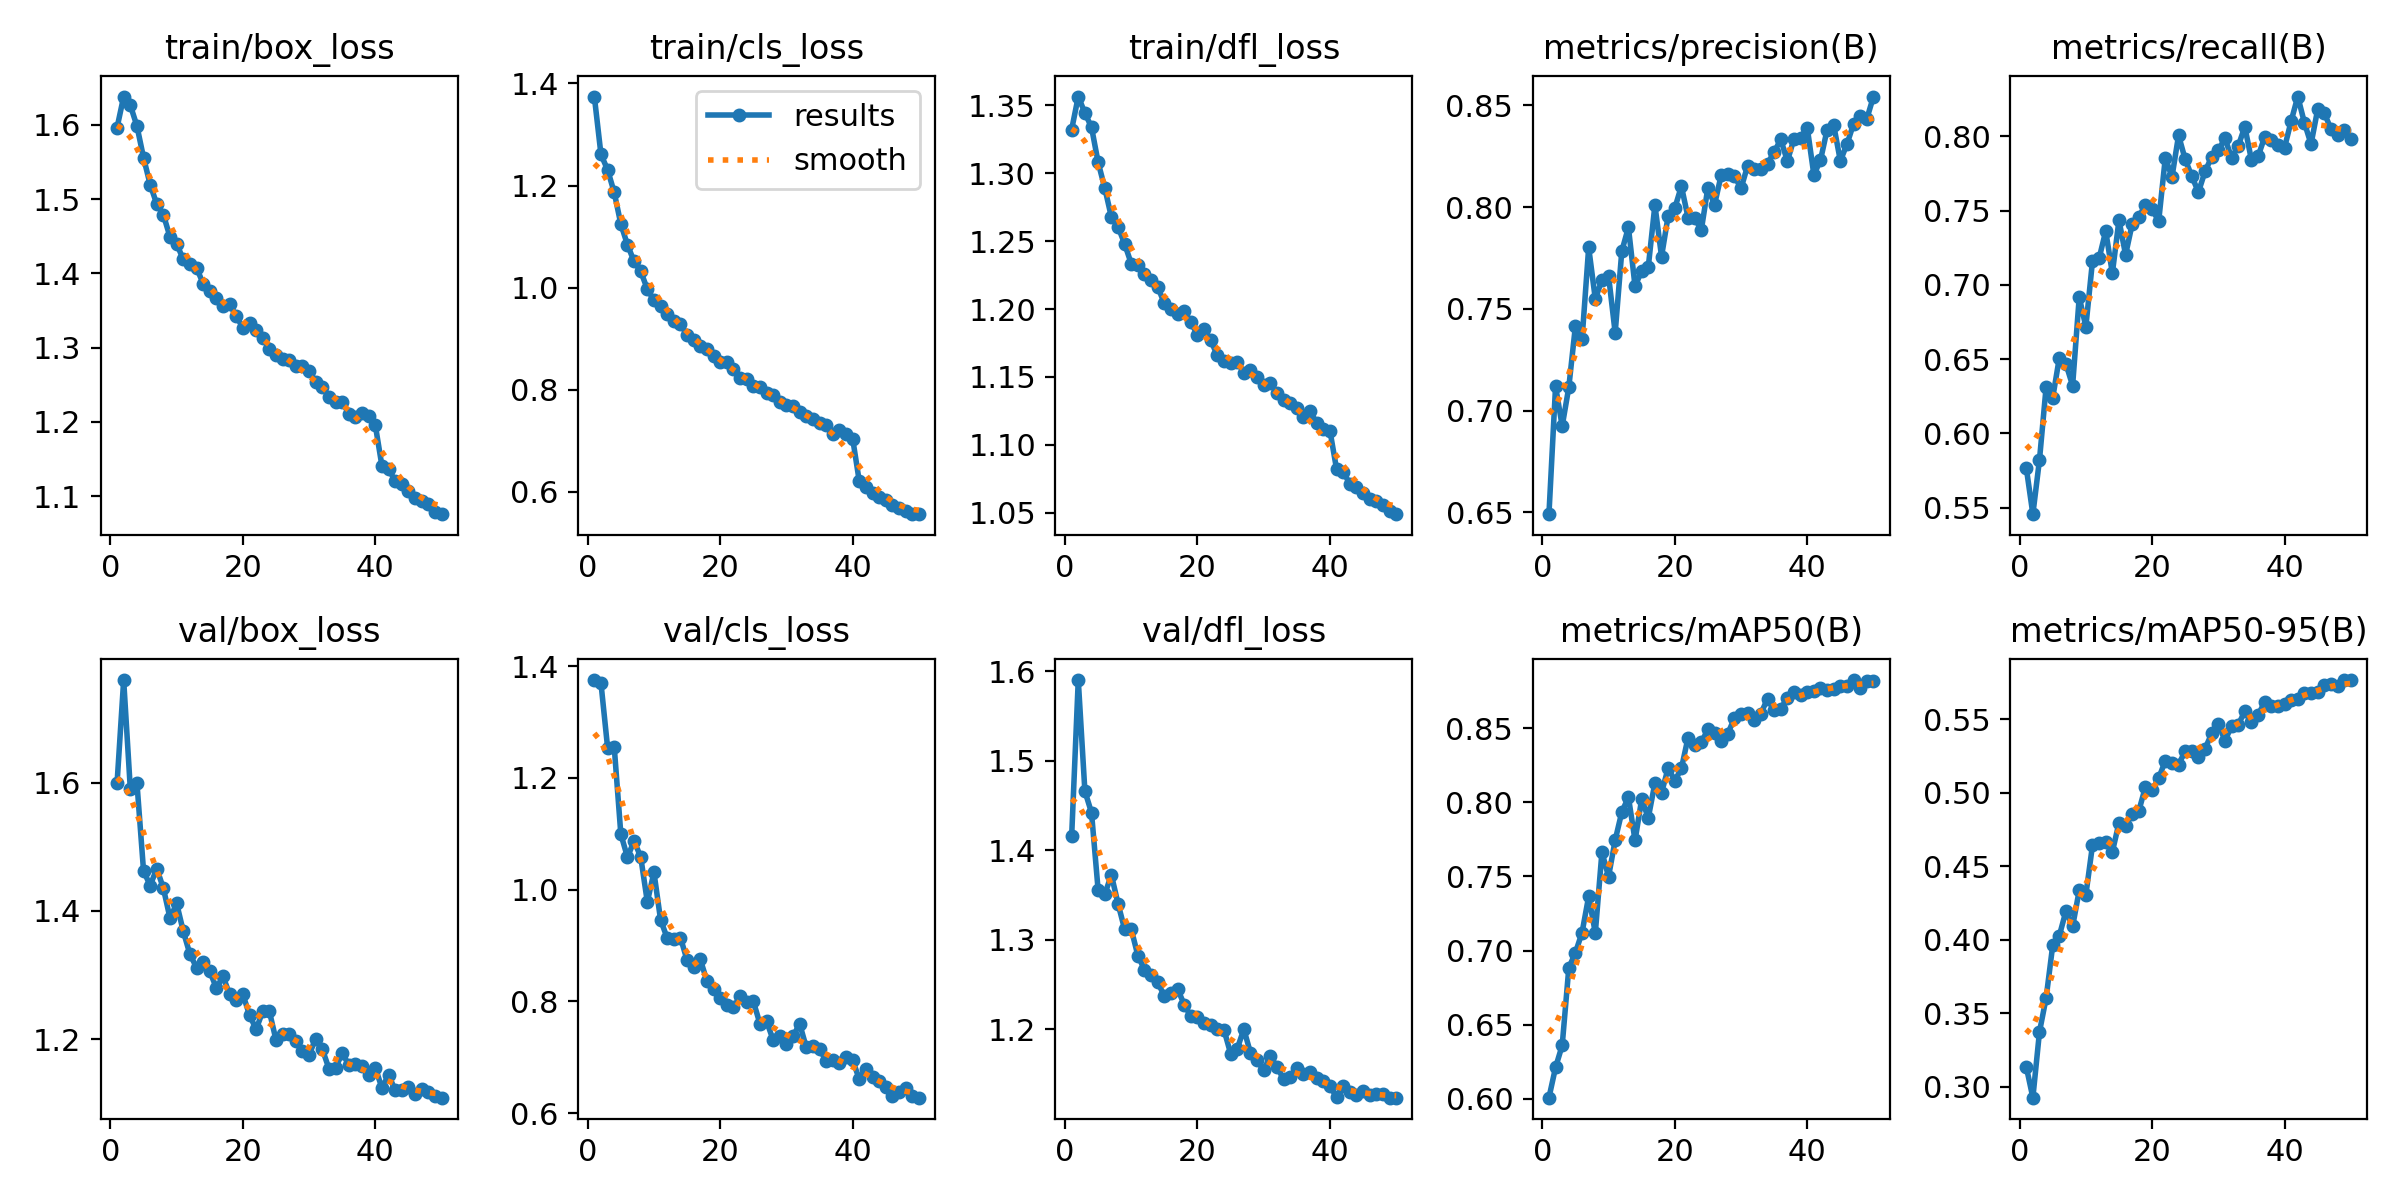

In [5]:
# Check Training Results
from IPython.display import Image

Image(filename='/content/drive/MyDrive/ChickenCount/runs/ChickenCount/results.png', width=900)

#### Count Chickens in a Video

In [7]:
from ultralytics import YOLO
import supervision as sv
import cv2
import numpy as np

MODEL_PATH  = "/content/drive/MyDrive/ChickenCount/runs/ChickenCount/weights/best.pt"
VIDEO_PATH  = "/content/drive/MyDrive/ChickenCount/a.mp4"
OUTPUT_PATH = "/content/drive/MyDrive/ChickenCount/output_counted.mp4"
CONFIDENCE  = 0.6

# Load trained model
model = YOLO(MODEL_PATH)

# Setup ByteTrack tracker
tracker = sv.ByteTrack()

# Setup drawing tools
box_annotator   = sv.BoxAnnotator(thickness=2)
label_annotator = sv.LabelAnnotator(text_scale=0.5)

# Open video
cap = cv2.VideoCapture(VIDEO_PATH)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

line_x      = width // 2
crossed_ids = set()  # remember chickens that crossed the line

# Output video writer
out = cv2.VideoWriter(OUTPUT_PATH, cv2.VideoWriter_fourcc(*'mp4v'), fps, (width, height))

# Track unique chicken IDs
all_ids   = set()
frame_num = 0

print(f"Processing {total_frames} frames...\n")

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    frame_num += 1

    # Detect
    result     = model(frame, conf=CONFIDENCE, verbose=False)[0]
    detections = sv.Detections.from_ultralytics(result)

    # Track
    detections = tracker.update_with_detections(detections)

    # Filter out crossed and right-side chickens
    if len(detections) > 0 and detections.tracker_id is not None:
        for i in range(len(detections)):
            x1  = detections.xyxy[i][0]
            tid = detections.tracker_id[i]
            if x1 >= line_x:
                crossed_ids.add(tid)  # mark as crossed

        left_mask  = np.array([
            (detections.xyxy[i][0] < line_x) and (detections.tracker_id[i] not in crossed_ids)
            for i in range(len(detections))
        ])
        detections = detections[left_mask]

    # Collect unique IDs
    if detections.tracker_id is not None:
        all_ids.update(detections.tracker_id.tolist())

    total_unique  = len(all_ids)
    current_count = len(detections)

    # Draw boxes and labels
    labels = [f"#{tid}" for tid in (detections.tracker_id if detections.tracker_id is not None else [])]
    frame  = box_annotator.annotate(scene=frame, detections=detections)
    frame  = label_annotator.annotate(scene=frame, detections=detections, labels=labels)

    # Draw red vertical line
    cv2.line(frame, (line_x, 0), (line_x, height), (0, 0, 255), 2)

    # Draw count panel
    cv2.rectangle(frame, (10, 10), (350, 80), (0, 0, 0), -1)
    cv2.putText(frame, f"In frame now : {current_count}", (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0),   2)
    cv2.putText(frame, f"Total unique : {total_unique}",  (20, 70), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 200, 255), 2)

    out.write(frame)

    if frame_num % 50 == 0:
        print(f"  Frame {frame_num}/{total_frames}")

cap.release()
out.release()

print(f"\nDone!")
print(f"Output saved to  : {OUTPUT_PATH}")
print(f"Total unique chickens counted: {len(all_ids)}")

Processing 343 frames...

  Frame 50/343
  Frame 100/343
  Frame 150/343
  Frame 200/343
  Frame 250/343
  Frame 300/343

Done!
Output saved to  : /content/drive/MyDrive/ChickenCount/output_counted.mp4
Total unique chickens counted: 13


#### Count on a Single Image


image 1/1 /content/drive/MyDrive/ChickenCount/image.jpg: 320x416 4 chickens, 66.9ms
Speed: 1.1ms preprocess, 66.9ms inference, 2.0ms postprocess per image at shape (1, 3, 320, 416)
🐔 Chickens detected: 4


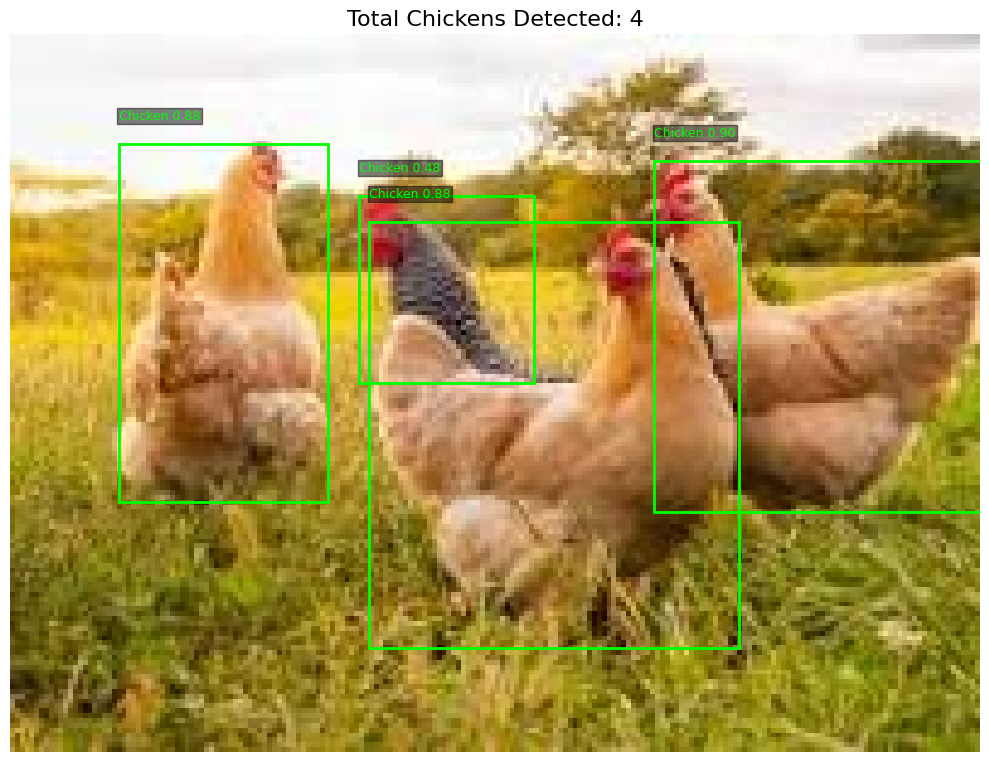

In [8]:
from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

MODEL_PATH = "/content/drive/MyDrive/ChickenCount/runs/ChickenCount/weights/best.pt"
IMAGE_PATH = "/content/drive/MyDrive/ChickenCount/image.jpg"
model  = YOLO(MODEL_PATH)
result = model(IMAGE_PATH, conf=0.4)[0]

count = len(result.boxes)
print(f"🐔 Chickens detected: {count}")

# Draw boxes
img = Image.open(IMAGE_PATH)
fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(img)

for box in result.boxes:
    x1, y1, x2, y2 = box.xyxy[0].tolist()
    conf = float(box.conf[0])
    rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                               linewidth=2, edgecolor='lime', facecolor='none')
    ax.add_patch(rect)
    ax.text(x1, y1 - 5, f"Chicken {conf:.2f}", color='lime', fontsize=9,
            bbox=dict(facecolor='black', alpha=0.5, pad=1))

ax.set_title(f"Total Chickens Detected: {count}", fontsize=16)
ax.axis('off')
plt.tight_layout()
plt.show()